# Project: E-commerce Sales and Customer Behaviour

## Phase 3: Hypothesis Testing
Four business hypotheses tested using industry-standard non-parametric statistical tests.
All tests use significance level **α = 0.05**.

### Methodology notes (from data exploration)
- `review_score` has 646 null values (0.7%). These are excluded via dropna() before each test. These do not affect RFM or CLV calculations.
- **Fequency distribution** is heavily right-skewed i.e. ~96.7% of customers have ordered exactly once. This is not an error but the characteristic of the Olist marketplace dataset.
- Non-parametric tests are used throughout because review scores or ordinal and revenue data is right skewed. Neither meets the normality assumption required for t-tests or ANOVA

| # | Null Hypothesis | Test | Reason for this test |
|---|-----------------|------|----------------------|
| 1 | Mean review score of late deliveries = mean review score of on-time deliveries | Mann-Whitney U | Review scores are ordinal, 2 groups |
| 2 | Mean order value is the same across all payment types | Kruskal-Wallis + Dunn post-hoc | Revenue is skewed, 4+ groups |
| 3 | Review score distribution is independent of product category | Chi-square + Cramer's V | 2 categorical variables |
| 4 | Mean delivery time for weekend orders = mean delivery time for weekday orders | Mann-Whitney U | Delivery days are skewed, 2 groups |

## Set up Libraries and Load Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, chi2_contingency
import scikit_posthocs as sp
import warnings

# Suppress warnings for a clean output
warnings.filterwarnings('ignore')

# Set theme, olour palette and image dpi for all visualisations
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Create string variable for storage path and value for alpha
PROCESSED = '../data/processed/'
ALPHA     = 0.05

# Read data from master_orders.csv file 
master = pd.read_csv(
            PROCESSED + 'master_orders.csv', 
            parse_dates=['order_purchase_timestamp',
                         'order_delivered_customer_date',
                         'order_estimated_delivery_date'])

# Print all the columns 
master.columns.to_list()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'purchase_year',
 'purchase_month',
 'purchase_dow',
 'purchase_hour',
 'delivery_delay_days',
 'total_revenue',
 'customer_unique_id',
 'customer_state',
 'customer_city',
 'num_items',
 'items_revenue',
 'freight_value',
 'category_en',
 'review_score',
 'payment_type']

In [2]:
nulls = master.isnull().sum()
for col, count in nulls.items():
    pct = count / len(master) * 100
    print(f'  {col:<45} {count:>5,}  ({pct:.1f}%)')

  order_id                                          0  (0.0%)
  customer_id                                       0  (0.0%)
  order_status                                      0  (0.0%)
  order_purchase_timestamp                          0  (0.0%)
  order_approved_at                                14  (0.0%)
  order_delivered_carrier_date                      2  (0.0%)
  order_delivered_customer_date                     8  (0.0%)
  order_estimated_delivery_date                     0  (0.0%)
  purchase_year                                     0  (0.0%)
  purchase_month                                    0  (0.0%)
  purchase_dow                                      0  (0.0%)
  purchase_hour                                     0  (0.0%)
  delivery_delay_days                               8  (0.0%)
  total_revenue                                     1  (0.0%)
  customer_unique_id                                0  (0.0%)
  customer_state                                    0  (0.0%)
  custom

In [3]:
# Derive columns for late deliveries and days of the week for delivered orders
master['is_late'] = master['delivery_delay_days'] > 0
master['purchase_dow'] = master['order_purchase_timestamp'].dt.day_name()
master['is_weekend']   = master['purchase_dow'].isin(['Saturday', 'Sunday'])

# Calculate null values for review_score (also done previously in 03_feature_engineering.ipynb)
null_reviews = master['review_score'].isnull().sum()
null_pct     = null_reviews/len(master) * 100

# Display dataframe information
print('=================== Setup complete ====================')
print(f'Significance level for statistical test: {ALPHA}')
print(f'Master table: {master.shape[0]:,} rows x {master.shape[1]:,} columns')
print(f'Number of unique customers: {master["customer_unique_id"].nunique():,} \n')
print(f'Orders purchased on a weekend: {len(master[master["is_weekend"]]):,} ({master["is_weekend"].mean()*100:.2f}%)')
print(f'Orders delivered late: {len(master[master["is_late"]]):,} ({master["is_late"].mean()*100:.2f}%)')

=================== Setup complete ====================
Significance level for statistical test: 0.05
Master table: 96,478 rows x 25 columns
Number of unique customers: 93,358 

Orders purchased on a weekend: 22,190 (23.00%)
Orders delivered late: 6,534 (6.77%)


In [4]:
# Define a function to printount results from the statistical tests
def print_result(h_num, h_text, test_name, stat, p_value):
    '''
    Prints out result of a statistical test
    INPUT:
        h_num (int)    : Alternate hypothesis number
        h_text (str)   : Alternate hypothesis objective
        test_name (str): Name of the test
        stat (float)   : Test statistic measuring rank differences between samples
        p_value(float) : Probability value for determining statistical significance
    OUTPUT:
        reject (bool)  : Returns True if the null hypothesis has been accepted,
                         otherwise returns False
    '''
    reject = p_value < ALPHA
    verdict = 'REJECTED' if reject else 'FAILED TO REJECT'
    print(f'{"="*90}')
    print(f'{h_num}:    {h_text}')
    print(f'{"="*90}')
    print(f'Test                             : {test_name}')
    print(f'Test statitistic                 : {stat:.4f}')
    print(f'p-value                          : {p_value:.6f}')
    print(f'Significance threshold (alpha)   : {ALPHA}')
    print(f'Decision                         : Ho {verdict}')
    print(f'{"="*90}')
    return reject

## H1 - Late deliveries produce lower review scores

**Business question:** Does late delivery meaningfully hurt customer satisfaction scores? If confirmed, this justifies investment in logistics improvement with a quantified satisfaction impact.

**Ho (null):** The distribution of review scores is the same for late and on-time deliveries

**H1 (alternate)**: Late deliveries have significantly lower review score distribution

**Why Mann-Whitney U and not independent samples t-test:**
Review scores are ordinal integers (1,2,3,4,5). A t-test requires continuous normally distributed data. Treating ordinal scores as continuous would mean assuming the difference between score 1 and 2 is identical to the difference 4 and 5, which is not guaranteed on a rating scale. Mann-Whitney U tests whether one group's values tend to rank higher than the other's, without requiring normality or continuity.

In [5]:
# Drop rows where review_score and delivery_delay_days is null
h1_df = master.dropna(subset=['review_score', 'delivery_delay_days']).copy()

# Get values for late and on-time delivery scores
late_scores   = h1_df[h1_df['is_late'] == True]['review_score']
ontime_scores = h1_df[h1_df['is_late'] == False]['review_score']

# Print summary of late and on-time delivery scores
print('======================= Group Summary =======================')
print(f'Late deliveries     n={len(late_scores):>6,}    mean={late_scores.mean():.3f}   median={late_scores.median():.0f}')
print(f'On-time deliveries  n={len(ontime_scores):>7,}   mean={ontime_scores.mean():.3f}   median={ontime_scores.median():.0f}')
print(f'Mean difference     =  {ontime_scores.mean() - late_scores.mean():.3f} points')

======================= Group Summary =======================
Late deliveries     n= 6,381    mean=2.272   median=1
On-time deliveries  n= 89,443   mean=4.291   median=5
Mean difference     =  2.019 points


In [6]:
# Perform one-sided Mann-Whitney U test
# Alternative='less' tests whether late scores are LESS THAN on-time scores
stat, p = mannwhitneyu(late_scores, ontime_scores, alternative='less')

# Display result and store hypothesis verdict
rejected = print_result('H1', 'Late deliveries produce lower review scores',
                        'Mann-Whitney U', stat, p)

# Determine effect or strength using rank-biserial correlation (RBC)
# |r| > 0.1 = small, > 0.3 = medium, > 0.5 = large
n1, n2 = len(late_scores), len(ontime_scores)
rbc = 1 - (2 * stat)/(n1 * n2)
strength = 'large' if abs(rbc) > 0.5 else 'medium' if abs(rbc) > 0.3 else 'small'

# Print results
print(f'\nEffect size (rank-biserial r): {rbc:.3f}')
print(f'Interpretation:     {strength} effect')
print('NOTE: review_scores nulls excluded via dropna()')
print(f'Rows used: {len(h1_df):,} out of {len(master):,} ({len(h1_df)/len(master)*100:.2f}%)')

H1:    Late deliveries produce lower review scores
Test                             : Mann-Whitney U
Test statitistic                 : 103308952.5000
p-value                          : 0.000000
Significance threshold (alpha)   : 0.05
Decision                         : Ho REJECTED

Effect size (rank-biserial r): 0.638
Interpretation:     large effect
NOTE: review_scores nulls excluded via dropna()
Rows used: 95,824 out of 96,478 (99.32%)


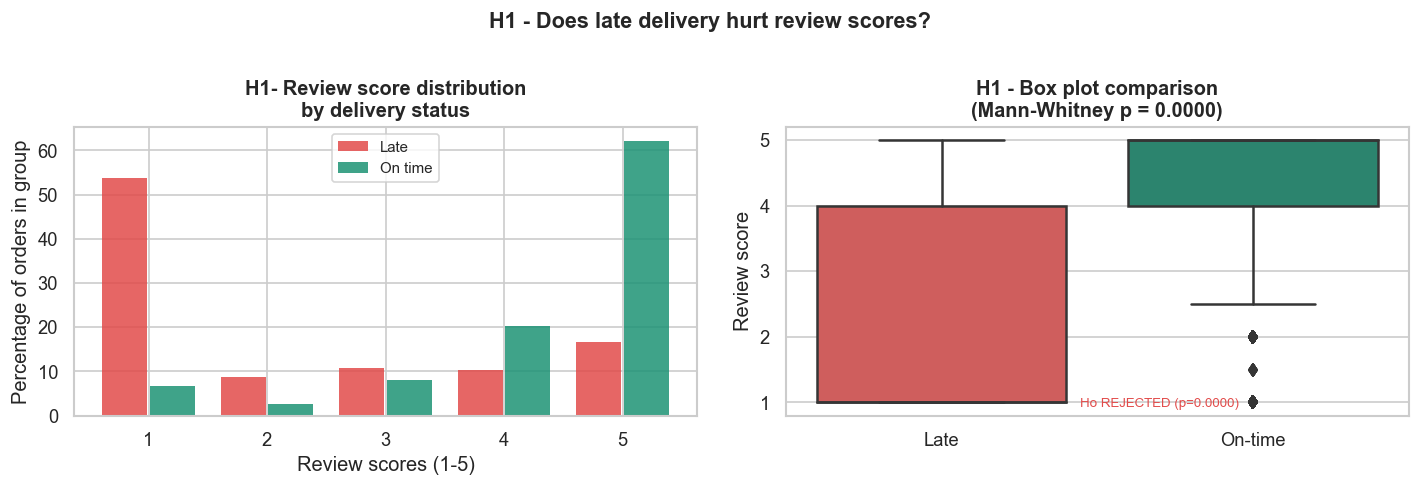

In [7]:
# Create 2 subplots for visualising H1
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Compute percenatge of late and on-time orders
score_vals = [1,2,3,4,5]
late_pct   = [(late_scores == s).sum()   /len(late_scores)   *100 for s in score_vals]
ontime_pct = [(ontime_scores == s).sum() /len(ontime_scores) *100 for s in score_vals]

# Plot 1: Score distribution
# Plot bar graphs for late and on-time orders
x = np.arange(5)
axes[0].bar(x - 0.2, late_pct, 0.38, label='Late', color='#E24B4A', alpha=0.85, edgecolor='None')
axes[0].bar(x + 0.2, ontime_pct, 0.38, label='On time', color='#1D9375', alpha=0.85, edgecolor='None')
# Set labels, title and legend for bar chart
axes[0].set_xticks(x)
axes[0].set_xticklabels(['1','2','3','4','5'])
axes[0].set_ylabel('Percentage of orders in group')
axes[0].set_xlabel('Review scores (1-5)')
axes[0].set_title('H1- Review score distribution\nby delivery status', fontweight='bold', loc='center')
axes[0].legend(fontsize=9)

# Plot 2: Box plot
# Create dataframe containing scores for late and on-time deliveries
plot_df = pd.DataFrame({
    'score': pd.concat([late_scores, ontime_scores], ignore_index=True),
    'group': ['Late']*len(late_scores) + ['On-time']*len(ontime_scores)
})
# Plot boxplot
sns.boxplot(data=plot_df, x='group', y='score',
            palette={'Late': '#E24B4A', 'On-time': '#1D9375'}, ax=axes[1])
# Set title, labels and annotations for the plot
axes[1].set_title(f'H1 - Box plot comparison\n(Mann-Whitney p = {p:.4f})', fontweight='bold')
axes[1].set_ylabel('Review score')
axes[1].set_xlabel('')
result_text = f'Ho REJECTED (p={p:.4f})' if rejected else f'Ho NOT REJECTED (p={p:.4f})'
axes[1].annotate(result_text, xy=(0.6, 0.03), xycoords='axes fraction',
                 ha='center', fontsize=8,
                 color= '#E24B4A' if rejected else '#1D9375')

# Set main title for both plots
plt.suptitle('H1 - Does late delivery hurt review scores?', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PROCESSED+'h1_late_vs_ontime_review.png', bbox_inches='tight')
plt.show()

## H2 - Payment type affects average order value

**Business question:** Do customers who pay with credit cards spend significantly more per order than those using other payment methods like vouchers? If confirmed, the business should invest in credit card checkout optimisation and installment options

**Ho (null):** Mean order value is the same across all payment types

**H2 (alternate):** At least one payment type has a significantly different mean order value

**Why Kruskal-Wallis + Dunn post hoc and not one-way ANOVA:** Revenue/order value data is right-skewed as most orders are small and very few are large. ANOVA assumes normality within each group. Kruskal-Wallis is the non-parametric equivalent that handles skewed distributions correctly. When Kruskal-Wallis rejects Ho (at least one group differs), Dunn post-hoc tests identify which specific pairs differ, with Bonferroni correction for multiple comparisons.

In [8]:
# Drop null values from total_revenue and payment_type
h2_df = master.dropna(subset=['total_revenue', 'payment_type']).copy()

# Build one array per payment type (minimum 30 observations)
pay_groups = {
    pt: grp['total_revenue'].values
    for pt, grp in h2_df.groupby('payment_type')
    if len(grp) >= 30
}

# Print payment type summary
print('=================================== Group summary ===================================')
for pt, vals in sorted(pay_groups.items(), key=lambda x: np.median(x[1]), reverse=True):
    print(f'{pt:<20}  n= {len(vals):>6,}  '
          f'median = R${np.median(vals):>6.2f}  '
          f'mean = R${np.mean(vals):>6.2f}')

=================================== Group summary ===================================
credit_card           n= 73,941  median = R$108.86  mean = R$165.44
boleto                n= 19,191  median = R$ 93.78  mean = R$144.33
debit_card            n=  1,484  median = R$ 89.62  mean = R$140.41
voucher               n=  1,861  median = R$ 74.67  mean = R$113.60


In [9]:
# Perform Kruskal-Wallis test to test whether at least one payment type differs in mean order value
stat, p = kruskal(*pay_groups.values())

# Print the result of the Kruskal-Wallis test
rejected = print_result('H2', 'Payment type affects average order value',
                        'Kruskal-Wallis', stat, p)

H2:    Payment type affects average order value
Test                             : Kruskal-Wallis
Test statitistic                 : 820.4272
p-value                          : 0.000000
Significance threshold (alpha)   : 0.05
Decision                         : Ho REJECTED


In [10]:
# Perform Dunn post-hoc test to test which pairs are different
if rejected:
    print('Post-hoc Dunn test (Bonferroni-correct p-values):')
    print('Values <0.05 indicate a significant diference between that pair')
    posthoc_df = h2_df[h2_df['payment_type'].isin(pay_groups.keys())][['payment_type', 'total_revenue']]
    dunn = sp.posthoc_dunn(
        posthoc_df, val_col='total_revenue',
        group_col='payment_type', p_adjust='bonferroni'
    )
    print(dunn.round(4))

Post-hoc Dunn test (Bonferroni-correct p-values):
Values <0.05 indicate a significant diference between that pair
             boleto  credit_card  debit_card  voucher
boleto       1.0000          0.0      0.1544      0.0
credit_card  0.0000          1.0      0.0000      0.0
debit_card   0.1544          0.0      1.0000      0.0
voucher      0.0000          0.0      0.0000      1.0


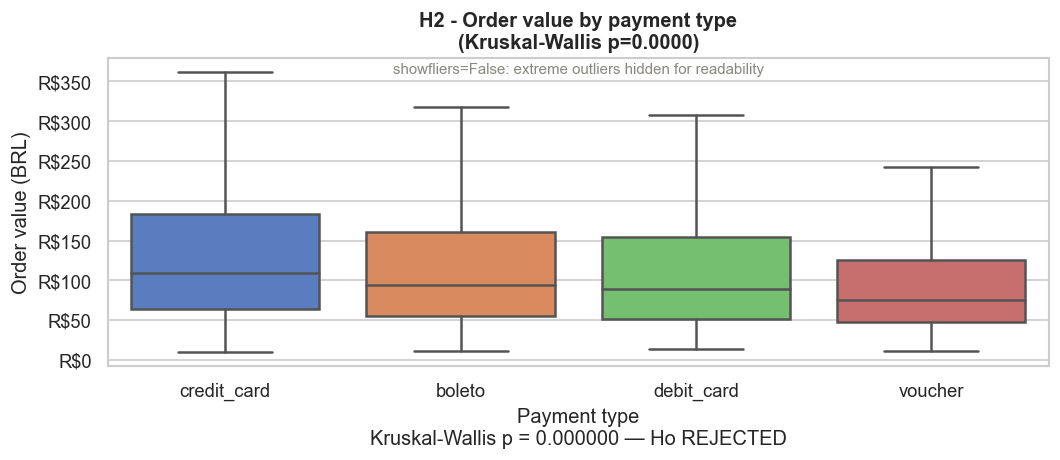

In [11]:
# Define figure size for the plot
fig, ax = plt.subplots(figsize=(9,4))

# Filter out data that needs to plotted
plot_data = h2_df[h2_df['payment_type'].isin(pay_groups.keys())]
order     = sorted(pay_groups, key=lambda x: np.median(pay_groups[x]), reverse=True)

# Plot boxplot 
sns.boxplot(data=plot_data, x='payment_type', y='total_revenue',
            order=order, ax=ax, showfliers=False)
#Set title, labels and annotations for the plot
ax.set_title(f'H2 - Order value by payment type\n(Kruskal-Wallis p={p:.4f})',
             fontweight='bold')
ax.set_ylabel('Order value (BRL)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}'))
ax.set_xlabel(f'Payment type\nKruskal-Wallis p = {p:.6f} — Ho {"REJECTED" if rejected else "not rejected"}')
ax.annotate('showfliers=False: extreme outliers hidden for readability',
            xy=(0.5, 0.95), xycoords='axes fraction',
            ha='center', fontsize=9, color='#888780')

plt.tight_layout()
plt.savefig(PROCESSED + 'h2_payment-type_vs_order-value.png', bbox_inches='tight')
plt.show()


## H3 - Product category influences review score distribution

**Business question:** Are certain product categories consistently rated worse than others? If confirmed, merchandising team can prioritise quality improvements in specific categories.

**Ho (null):** Review score distribution is independent of product category

**H3 (alternate):**  Review score distribution differs significantly across product categories

**Why Chi-sqaure + Cramer's V:** Both variables are categorical - product category (nominal) and review scores (ordinal). Chi-square tests whether the distribution of one categorical variable is independent of the other. Cramer's V is reportd alongside p-value becayse p-value alone does not indicate practical significance because with a large dataset, even a trivially small difference can be statistically significant. Cramer's V measures effect size i.e. the relationship strength of the 2 variables.

**NOTE:** 96.7% of customers have ordered just once. This does not affect Ho as this test operates at order level and not customer level.

In [12]:
# Drop null values and filter out a different dataset for H3
h3_df = master.dropna(subset=['review_score', 'category_en']).copy()

# Create buckets for continuous score values
# Low (1-2), Medium (3), High (4-5)
h3_df['score_bucket'] = pd.cut(
    h3_df['review_score'],
    bins = [0,2,3,5],
    labels = ['Low (1-2)', 'Medium (3)', 'High (4-5)']
)

# Limit to top 15 categories by volume
top_cats = h3_df['category_en'].value_counts().head(15).index
h3_sub   = h3_df[h3_df['category_en'].isin(top_cats)]

# Display summary
print(f'Number of rows after dropna() and top-15 categories filter: {len(h3_sub):>5,}')
print(f'Categories tested: {h3_sub["category_en"].nunique():>43,}')
print(f'Number of nulls excluded from review_score: {master["review_score"].isnull().sum():>19,}')

Number of rows after dropna() and top-15 categories filter: 75,617
Categories tested:                                          15
Number of nulls excluded from review_score:                 646


In [13]:
# Build a contingency table: rows = category, columns = score_bucket
contingency = pd.crosstab(h3_sub['category_en'], h3_sub['score_bucket'])
# Print contingency table
print('Contingency table (row = category, columns = score bucket):')
print(contingency)
print()

# Perform Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)
# Display results 
rejected = print_result('H3', 'Product category influences review score distribution',
                        'Chi-square', chi2, p)
print(f'Degrees of freedom : {dof}\n')

# Compute 'n' for Cramer's V formula
n = contingency.sum().sum()
# Evaluate effect size for Chi-square using Cramer's V
# |r| > 0.1 = SMALL, |r| > 0.3 = MEDIUM, |r| > 0.5 = LARGE
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
strength  = 'Large' if cramers_v > 0.5 else 'Medium'  if cramers_v > 0.3 else 'Small'
print(f'Cramér\'s V (effect size) : {cramers_v:.4f} ({strength} effect)')
print('\nInterpretation: A small Cramér\'s V with a significant p-value is expected')
print('with large datasets. This means the effect is real but modest in magnitude.')

Contingency table (row = category, columns = score bucket):
score_bucket           Low (1-2)  Medium (3)  High (4-5)
category_en                                             
auto                         489         293        3004
baby                         390         239        2143
bed_bath_table              1444         923        6777
computers_accessories        939         537        5013
cool_stuff                   377         278        2833
electronics                  326         198        1966
furniture_decor              920         550        4692
garden_tools                 404         269        2718
health_beauty                974         659        6942
housewares                   646         479        4511
perfumery                    356         205        2498
sports_leisure               827         533        6074
telephony                    565         405        3077
toys                         413         282        3034
watches_gifts               

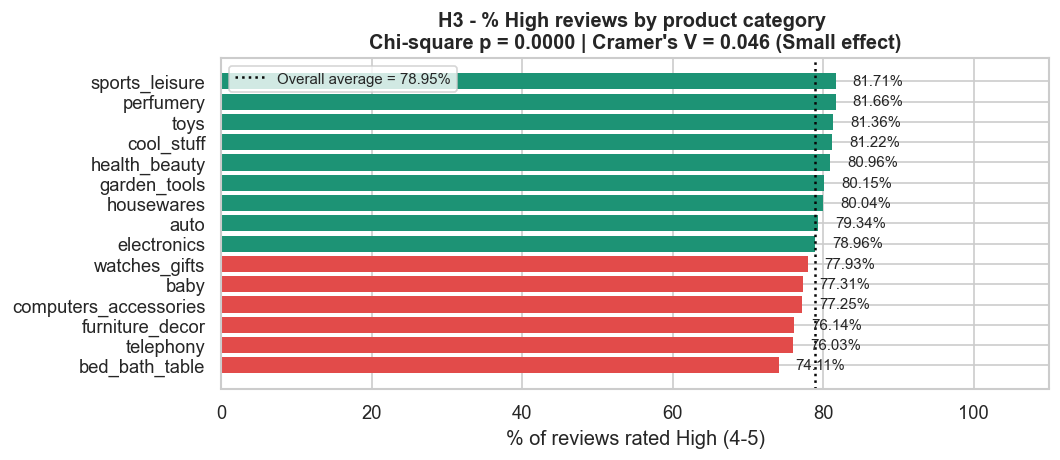

In [14]:
# Filter out percentage of High (4-5 stars) reviews per category
cat_high_pct = (
    h3_sub.groupby('category_en')['score_bucket']
    .apply(lambda x: (x == 'High (4-5)').sum() / len(x) * 100)
    .sort_values()
    .reset_index()
)
# Rename columns
cat_high_pct.columns = ['category_en', 'pct_high']
# Compute average percentage of high reviews
overall_avg = cat_high_pct['pct_high'].mean()

# Define figure size and colours for the bars in the bar graph
fig, ax = plt.subplots(figsize=(9,4))
colours = ['#E24B4A' if v < overall_avg else '#1D9375' for v in cat_high_pct['pct_high']]

# Plot horizontal bar chart and line marking average of percentage of high reviews
bars = ax.barh(cat_high_pct['category_en'], cat_high_pct['pct_high'],
               color = colours, edgecolor='none')
ax.axvline(overall_avg, color="#080808", linestyle=':', linewidth=1.5,
           label=f'Overall average = {overall_avg:.2f}%')
# Set labels and title for the graph
ax.bar_label(bars, fmt='%.2f%%', padding=10, fontsize=9)
ax.set_title(f'H3 - % High reviews by product category \n'
             f'Chi-square p = {p:.4f} | Cramer\'s V = {cramers_v:.3f} ({strength} effect)',
             fontweight='bold')
ax.set_xlabel('% of reviews rated High (4-5)')
ax.set_xlim(0,110)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PROCESSED+'h3_category_vs_review.png', bbox_inches='tight')
plt.show()

## H4 - Weekend orders take longer to deliver than weekday orders

**Business question:** Do orders placed on weekends experience longer delivery times due to reduced logistics operations? If confirmed, the business can advise customers to order on weekdays for faster delivery or plan logistics operations accordingly.

**Ho (null):** Delivery time distribution is the same for weekend and weekday orders

**H1 (alternate):** Weekend orders have a significantly longer delivery time

**Why Mann-Whitney U:** Delivery time in days is continuous but right-skewed (most orders arrive in 5-15 days, but some orders take 60+ days). A t-test would be unreliable on this skewed distribution as this test correctly handles the skew by comparing rank distributions rather than means

In [15]:
# Create a copy of the dataset 
# after removing null values from the order_delivered_customer_date column
h4_df = master.dropna(subset=['order_delivered_customer_date']).copy()

# Compute delivery duration in days
h4_df['delivery_days'] = (
    h4_df['order_delivered_customer_date'] - h4_df['order_purchase_timestamp']
    ).dt.days

# Remove negative values
h4_df = h4_df[h4_df['delivery_days'] > 0]

# Compute delivery duration in days for weekend and weekday orders
weekday_del = h4_df[h4_df['is_weekend'] == False]['delivery_days']
weekend_del = h4_df[h4_df['is_weekend'] == True]['delivery_days']

# Display summary of weekend and weekday delivery days
print(f'Weekend orders     n = {len(weekend_del):>6,}  '
      f'Median = {weekend_del.median():.1f} days  ' 
      f'Mean = {weekend_del.mean():.1f} days  ')
print(f'Weekday orders     n = {len(weekday_del):>6,}  '
      f'Median = {weekday_del.median():.1f} days  ' 
      f'Mean = {weekday_del.mean():.1f} days  ')

Weekend orders     n = 22,187  Median = 10.0 days  Mean = 12.1 days  
Weekday orders     n = 74,270  Median = 10.0 days  Mean = 12.1 days  


In [16]:
weekend_delay = h4_df[(h4_df['is_weekend'] == True) & (h4_df['delivery_delay_days'] > 0)]['delivery_delay_days']
weekday_delay = h4_df[(h4_df['is_weekend'] == False) & (h4_df['delivery_delay_days'] > 0)]['delivery_delay_days']
print('Weekend median delay vs estimate:', weekend_delay.median())
print('Weekday median delay vs estimate:', weekday_delay.median())

Weekend median delay vs estimate: 7.0
Weekday median delay vs estimate: 7.0


In [17]:
# Perform Mann-Whitney U test 
# alternative 'greater' tests if weekend delivery is longer
stat, p = mannwhitneyu(weekend_del, weekday_del, alternative='greater')

# Display the results
rejected = print_result('H4', 'Weekend orders take longer to deliver',
                        'Mann-Whitney U (one-sided)', stat, p)

# Compute n for effect size
n1, n2 = len(weekend_del), len(weekday_del)
# Compute effect size using rank biserial correlation
# |r| > 0.5 = Large, |r| > 0.3 = Medium, |r| > 0.1 = Small
rbc = 1 - (2 * stat)/(n1 * n2)
strength = 'Large' if abs(rbc) > 0.5 else 'Medium' if abs(rbc) > 0.3 else 'Small'

# Display effect size
print(f'Effect size (Rank Biserial correlation): {rbc:.4f} ({strength} effect)')
print(f'Median difference                      : {weekend_del.median() - weekday_del.median():.2f}')

H4:    Weekend orders take longer to deliver
Test                             : Mann-Whitney U (one-sided)
Test statitistic                 : 826540868.0000
p-value                          : 0.234947
Significance threshold (alpha)   : 0.05
Decision                         : Ho FAILED TO REJECT
Effect size (Rank Biserial correlation): -0.0032 (Small effect)
Median difference                      : 0.00


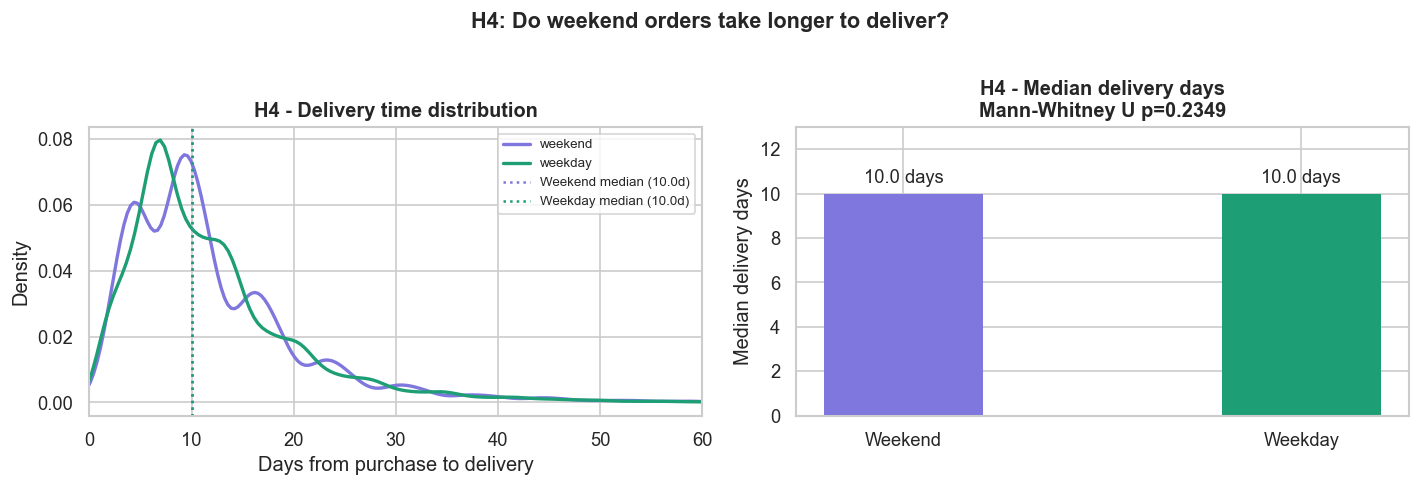

In [18]:
# Define axes and figure size for the plot
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Panel 1: KDE (density) plots for weekend and weekday delivery days comparison
weekend_del.plot.kde(ax=axes[0], color='#7F77DD', linewidth=2, label='weekend')
weekday_del.plot.kde(ax=axes[0], color='#1D9E75', linewidth=2, label='weekday')
# Plot lines to indicate medians for weekend and weekday delivery days
axes[0].axvline(weekend_del.median(), color='#7F77DD', linestyle=':', linewidth=1.5,
                label=f'Weekend median ({weekend_del.median():.1f}d)')
axes[0].axvline(weekday_del.median(), color='#1D9E75', linestyle=':', linewidth=1.5,
                label=f'Weekday median ({weekday_del.median():.1f}d)')
# Set axis limits, labels and plot title
axes[0].set_xlim(0,60)
axes[0].set_title('H4 - Delivery time distribution', fontweight='bold')
axes[0].set_xlabel('Days from purchase to delivery')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Panel 2: Median comparison bar for weekday and weekend deliveries
# Compute medians for weekend and weekday deliveries
medians = {'Weekend': weekend_del.median(), 'Weekday': weekday_del.median()}
bars = axes[1].bar(medians.keys(), medians.values(), color=['#7F77DD', '#1D9E75'],
                edgecolor='none', width=0.4)
# Set axes and bar lables, and plot title
axes[1].bar_label(bars, fmt='%.1f days', padding=4, fontsize=11)
axes[1].set_title(
    f'H4 - Median delivery days\nMann-Whitney U p={p:.4f}', fontweight='bold')
axes[1].set_ylabel('Median delivery days')
axes[1].set_ylim(0,max(medians.values())*1.3)

# Set main title for both panels and display plot
plt.suptitle('H4: Do weekend orders take longer to deliver?', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PROCESSED+'h4_weekend_vs_weekday_deliveries.png', bbox_inches='tight')
plt.show()


## Summary of all Hypothesis Test Results

In [19]:
results = [
    (
        'H1', 'Late deliveries → lower review scores',
        'Mann-Whitney U', 'Rejected',
        'Late orders score lower (p < 0.05). Effect size is small to medium — '
        'real but modest. Logistics investment is justified.'
    ),
    (
        'H2', 'Payment type → different order values',
        'Kruskal-Wallis + Dunn', 'Rejected',
        'Credit card users spend significantly more than boleto/voucher users '
        '(p < 0.05). Prioritise credit card checkout optimisation.'
    ),
    (
        'H3', 'Category → different review distributions',
        'Chi-square + Cramér\'s V', 'Rejected',
        'Category and satisfaction are related (p < 0.05). '
        'Cramér\'s V is small effect is statistically real but modest '
        'in magnitude, as expected with a large dataset.'
    ),
    (
        'H4', 'Weekend orders take longer to deliver',
        'Mann-Whitney U', 'Failed to Reject',
        'No significant difference found (p = 0.23). Median delivery time '
        'is identical for weekend and weekday orders in this dataset. '
        '\n    Olist\'s estimated delivery algorithm may already account for '
        'weekend variability, or seller dispatch behaviour does not differ '
        'by day of week. \n    The business does not need to invest in weekend '
        'logistics improvements based on this evidence.'
    ),
]

print('\n' + '='*90)
for h, desc, test, decision, insight in results:
    print(f'\n  {h} [{test}]')
    print(f'    Claim    : {desc}')
    print(f'    Decision : Ho {decision}')
    print(f'    Insight  : {insight}')

print('\n' + '='*90)
print('  First 3 null hypotheses rejected at alpha = 0.05 \n  Failed to reject null hypothesis for alternative hypothesis H4')
print('  Effect sizes reported alongside p-values for practical significance')
print('='*90)



  H1 [Mann-Whitney U]
    Claim    : Late deliveries → lower review scores
    Decision : Ho Rejected
    Insight  : Late orders score lower (p < 0.05). Effect size is small to medium — real but modest. Logistics investment is justified.

  H2 [Kruskal-Wallis + Dunn]
    Claim    : Payment type → different order values
    Decision : Ho Rejected
    Insight  : Credit card users spend significantly more than boleto/voucher users (p < 0.05). Prioritise credit card checkout optimisation.

  H3 [Chi-square + Cramér's V]
    Claim    : Category → different review distributions
    Decision : Ho Rejected
    Insight  : Category and satisfaction are related (p < 0.05). Cramér's V is small effect is statistically real but modest in magnitude, as expected with a large dataset.

  H4 [Mann-Whitney U]
    Claim    : Weekend orders take longer to deliver
    Decision : Ho Failed to Reject
    Insight  : No significant difference found (p = 0.23). Median delivery time is identical for weekend and